# Zone Partial Overlap

The oracle computes a **continuous** USDA zone overlap score:

```
overlap = max(0, min(user_max, plant_max) - max(user_min, plant_min) + 1)
zone_score = overlap / user_span
```

- **Full overlap (1.0):** plant thrives across the user's entire zone range
- **Partial (0 < x < 1):** some zones work, proportional credit
- **None (0.0):** plant can't survive in any of the user's zones

**Hypothesis:** Survival and model score should increase as overlap count grows. The model should learn the gradual nature of zone compatibility, not just binary match/mismatch.

## 1. Setup & Load Data

In [10]:
import json
import sys
import numpy as np
from collections import defaultdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "resources").exists():
    for c in [ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent]:
        if (c / "resources").exists():
            ROOT = c
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERACTIONS_PATH = ROOT / "resources" / "data" / "synthetic_interactions.json"
USERS_PATH = ROOT / "resources" / "data" / "synthetic_users.json"
PLANTS_PATH = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_normalized.json"
PLANTS_ALT = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_uniform.json"
OUTPUT_DIR = ROOT / "resources" / "verify" / "zone overlap"

## 2. Helper Functions

In [11]:
def _extract_plant_usda_zone(plant: dict) -> tuple[int, int]:
    ec = plant.get("environment_care") or {}
    min_z, max_z = ec.get("usda_zone_min"), ec.get("usda_zone_max")
    if min_z is not None and max_z is not None:
        return max(1, min(13, int(min_z))), max(1, min(13, int(max_z)))
    usda = ec.get("USDA Hardiness zone")
    if isinstance(usda, dict):
        min_z = usda.get("min", 3)
        max_z = usda.get("max", 9)
        return max(1, min(13, int(min_z))), max(1, min(13, int(max_z)))
    return (3, 9)


def compute_zone_overlap(user: dict, plant: dict) -> tuple[int, int] | None:
    """Return (overlap_count, user_span) or None if user has no zone info."""
    u_min, u_max = user.get("usda_zone_min"), user.get("usda_zone_max")
    if u_min is None or u_max is None:
        return None
    u_min, u_max = int(u_min), int(u_max)
    p_min, p_max = _extract_plant_usda_zone(plant)
    overlap = max(0, min(u_max, p_max) - max(u_min, p_min) + 1)
    user_span = u_max - u_min + 1
    return overlap, user_span

In [12]:
def load_data():
    with open(INTERACTIONS_PATH) as f:
        interactions = json.load(f)
    with open(USERS_PATH) as f:
        users = json.load(f)
    path = PLANTS_PATH if PLANTS_PATH.exists() else PLANTS_ALT
    with open(path) as f:
        plants = json.load(f).get("plants", [])
    user_by_id = {u["user_id"]: u for u in users}
    plant_by_id = {p.get("id"): p for p in plants if p.get("id") is not None}
    return interactions, user_by_id, plant_by_id

interactions, user_by_id, plant_by_id = load_data()
print(f"{len(interactions)} interactions, {len(user_by_id)} users, {len(plant_by_id)} plants")

11206 interactions, 810 users, 1000 plants


## 3. Compute Survival by Overlap Count

Group interactions by how many USDA zones overlap between user and plant. For each overlap count, compute survival rate, sample size, and 95% confidence interval.

In [13]:
def survival_by_overlap_count(interactions, user_by_id, plant_by_id):
    """Group by raw overlap zone count; return sorted list of dicts."""
    by_overlap = defaultdict(list)
    for r in interactions:
        u = user_by_id.get(r["user_id"], {})
        p = plant_by_id.get(r["plant_id"]) or {}
        if not p:
            continue
        result = compute_zone_overlap(u, p)
        if result is None:
            continue
        overlap, _ = result
        by_overlap[overlap].append(r.get("label", 0))

    stats = []
    for ov in sorted(by_overlap.keys()):
        labels = by_overlap[ov]
        n = len(labels)
        mean = sum(labels) / n
        se = (mean * (1 - mean) / n) ** 0.5 if n > 1 else 0
        stats.append({
            "overlap": ov,
            "n": n,
            "survival_rate": mean,
            "ci_low": max(0, mean - 1.96 * se),
            "ci_high": min(1, mean + 1.96 * se),
        })
    return stats

MAX_OVERLAP = 4  # overlap 5+ has too few samples to be meaningful

overlap_stats_all = survival_by_overlap_count(interactions, user_by_id, plant_by_id)
overlap_stats = [s for s in overlap_stats_all if s['overlap'] <= MAX_OVERLAP]
for s in overlap_stats_all:
    tag = '  <-- excluded (low n)' if s['overlap'] > MAX_OVERLAP else ''
    print(f"overlap={s['overlap']:2d}  survival={s['survival_rate']:.3f}  "
          f"95% CI=[{s['ci_low']:.3f}, {s['ci_high']:.3f}]  n={s['n']}{tag}")

overlap= 0  survival=0.588  95% CI=[0.574, 0.601]  n=5084
overlap= 1  survival=0.711  95% CI=[0.696, 0.727]  n=3414
overlap= 2  survival=0.708  95% CI=[0.687, 0.730]  n=1717
overlap= 3  survival=0.723  95% CI=[0.689, 0.758]  n=636
overlap= 4  survival=0.779  95% CI=[0.728, 0.829]  n=262
overlap= 5  survival=0.711  95% CI=[0.617, 0.805]  n=90  <-- excluded (low n)
overlap= 6  survival=1.000  95% CI=[1.000, 1.000]  n=3  <-- excluded (low n)


## 4. Plot: Survival vs Overlap Count (0–4, Line + Confidence Band)

Capped at overlap ≤ 4 — overlap 5 (n=90) and 6 (n=3) are too noisy to be meaningful. Line chart with dot size proportional to sample count. Shaded band shows 95% CI.

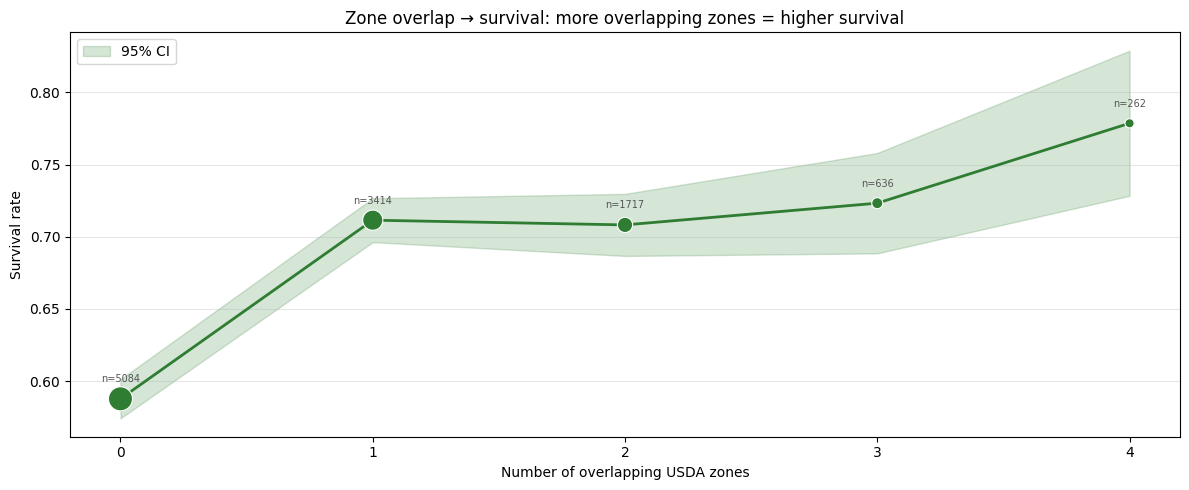

In [14]:
import matplotlib.pyplot as plt

overlaps = [s["overlap"] for s in overlap_stats]
survivals = [s["survival_rate"] for s in overlap_stats]
ci_lows = [s["ci_low"] for s in overlap_stats]
ci_highs = [s["ci_high"] for s in overlap_stats]
counts = [s["n"] for s in overlap_stats]

# scale dot size: min 30, max 300
max_n = max(counts) if counts else 1
sizes = [30 + 270 * (c / max_n) for c in counts]

fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")

ax.fill_between(overlaps, ci_lows, ci_highs, alpha=0.2, color="#2e7d32", label="95% CI")
ax.plot(overlaps, survivals, "-", color="#2e7d32", linewidth=2)
ax.scatter(overlaps, survivals, s=sizes, color="#2e7d32", zorder=5, edgecolors="white", linewidths=0.8)

for s in overlap_stats:
    ax.annotate(f"n={s['n']}", (s["overlap"], s["survival_rate"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=7, color="#555")

ax.set_xlabel("Number of overlapping USDA zones")
ax.set_ylabel("Survival rate")
ax.set_title("Zone overlap → survival: more overlapping zones = higher survival")
ax.set_xticks(overlaps)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "zone_overlap_survival.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

## 5. Model: Does It Learn the Gradual Zone Overlap?

Load the two-tower model and compute mean model score at each overlap count. Overlay on a dual y-axis with survival for comparison.

In [15]:
import torch
from resources.ETL.feature_engineer import apply_user_embeddings, apply_categorical_embeddings

users_list = list(user_by_id.values())
plants_list = list(plant_by_id.values())
apply_user_embeddings(users_list)
apply_categorical_embeddings(plants_list)
user_by_id = {u["user_id"]: u for u in users_list}
plant_by_id = {p.get("id"): p for p in plants_list}

model = None
for p in [ROOT / "resources" / "two_tower_training" / "two_tower.pt",
          ROOT / "resources" / "two_tower_training" / "output" / "two_tower.pt"]:
    if p.exists():
        ckpt = torch.load(p, map_location="cpu", weights_only=True)
        state = ckpt.get("model_state", ckpt)
        if any("user_tower.mlp" in k for k in state.keys()):
            from resources.two_tower_training.two_tower_model import TwoTowerModel
            model = TwoTowerModel()
            model.load_state_dict(state, strict=True)
            model.eval()
            print(f"Loaded model from {p}")
            break
if model is None:
    print("Model not found — skip model analysis.")

Loaded model from /Users/yemarnaung/Documents/Projects/HowToKeepYourPlantsAlive/resources/two_tower_training/output/two_tower.pt


In [16]:
def model_scores_by_overlap(interactions, user_by_id, plant_by_id, model):
    """Compute mean model score grouped by zone overlap count."""
    batch_u, batch_p, batch_ov = [], [], []
    for r in interactions:
        u = user_by_id.get(r["user_id"], {})
        p = plant_by_id.get(r["plant_id"]) or {}
        if not p or "categorical_embedding" not in p:
            continue
        u_emb = u.get("categorical_embedding")
        if not u_emb or len(u_emb) != 21:
            continue
        result = compute_zone_overlap(u, p)
        if result is None:
            continue
        overlap, _ = result
        batch_u.append(list(u_emb) + [0.0] * 64 + [0.0] * 64)
        batch_p.append(p["categorical_embedding"])
        batch_ov.append(overlap)

    if not batch_u:
        return None
    u_t = torch.tensor(batch_u, dtype=torch.float32)
    p_t = torch.tensor(batch_p, dtype=torch.float32)
    with torch.no_grad():
        scores = model(u_t, p_t).numpy()

    by_ov = defaultdict(list)
    for ov, sc in zip(batch_ov, scores):
        by_ov[ov].append(float(sc))
    return [
        {"overlap": ov, "n": len(v), "mean_score": sum(v) / len(v),
         "std": (sum((x - sum(v)/len(v))**2 for x in v) / len(v)) ** 0.5}
        for ov, v in sorted(by_ov.items())
    ]

model_overlap_all = model_scores_by_overlap(interactions, user_by_id, plant_by_id, model) if model else None
model_overlap = [s for s in model_overlap_all if s['overlap'] <= MAX_OVERLAP] if model_overlap_all else None
if model_overlap_all:
    for s in model_overlap_all:
        tag = '  <-- excluded (low n)' if s['overlap'] > MAX_OVERLAP else ''
        print(f"overlap={s['overlap']:2d}  model_score={s['mean_score']:.4f}  std={s['std']:.4f}  n={s['n']}{tag}")
else:
    print("Model not loaded — skip.")

overlap= 0  model_score=4.1788  std=1.6785  n=5084
overlap= 1  model_score=4.6281  std=1.5262  n=3414
overlap= 2  model_score=4.7311  std=1.5737  n=1717
overlap= 3  model_score=5.0499  std=1.1861  n=636
overlap= 4  model_score=5.1529  std=1.1694  n=262
overlap= 5  model_score=4.9069  std=1.1183  n=90  <-- excluded (low n)
overlap= 6  model_score=5.4336  std=1.2624  n=3  <-- excluded (low n)


## 6. Combined Plot: Survival + Model Score vs Overlap Count (0–4)

Dual y-axis line chart (overlap ≤ 4 only). Left: survival rate (green). Right: model score (blue). Both with confidence/std bands.

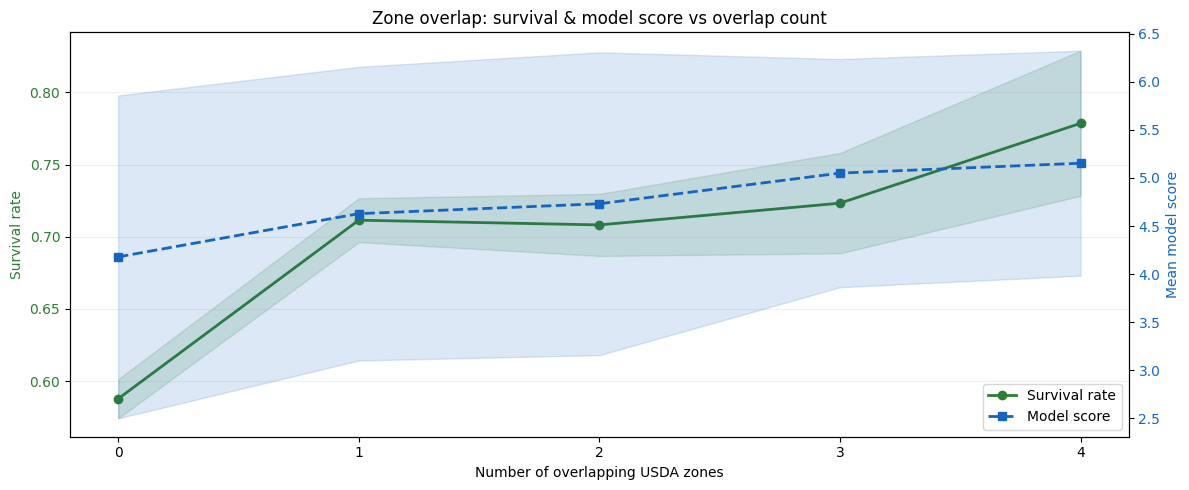

In [17]:
if model_overlap:
    m_overlaps = [s["overlap"] for s in model_overlap]
    m_scores = [s["mean_score"] for s in model_overlap]
    m_stds = [s["std"] for s in model_overlap]
    m_lo = [m - sd for m, sd in zip(m_scores, m_stds)]
    m_hi = [m + sd for m, sd in zip(m_scores, m_stds)]
    m_counts = [s["n"] for s in model_overlap]
    m_sizes = [30 + 270 * (c / max(m_counts)) for c in m_counts]

    fig, ax1 = plt.subplots(figsize=(12, 5), facecolor="white")
    ax2 = ax1.twinx()

    # survival (left axis)
    ax1.fill_between(overlaps, ci_lows, ci_highs, alpha=0.15, color="#2e7d32")
    ax1.plot(overlaps, survivals, "o-", color="#2e7d32", linewidth=2, markersize=6, label="Survival rate")

    # model score (right axis)
    ax2.fill_between(m_overlaps, m_lo, m_hi, alpha=0.15, color="#1565c0")
    ax2.plot(m_overlaps, m_scores, "s--", color="#1565c0", linewidth=2, markersize=6, label="Model score")

    ax1.set_xlabel("Number of overlapping USDA zones")
    ax1.set_ylabel("Survival rate", color="#2e7d32")
    ax2.set_ylabel("Mean model score", color="#1565c0")
    ax1.tick_params(axis="y", labelcolor="#2e7d32")
    ax2.tick_params(axis="y", labelcolor="#1565c0")
    ax1.set_title("Zone overlap: survival & model score vs overlap count")

    all_ticks = sorted(set(overlaps + m_overlaps))
    ax1.set_xticks(all_ticks)
    ax1.grid(axis="y", alpha=0.2)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "zone_overlap_model.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("Model not loaded — combined plot skipped.")

## 7. Overlap Fraction Distribution

Show how the overlap fraction (`overlap / user_span`) is distributed across all interactions, to understand data coverage.

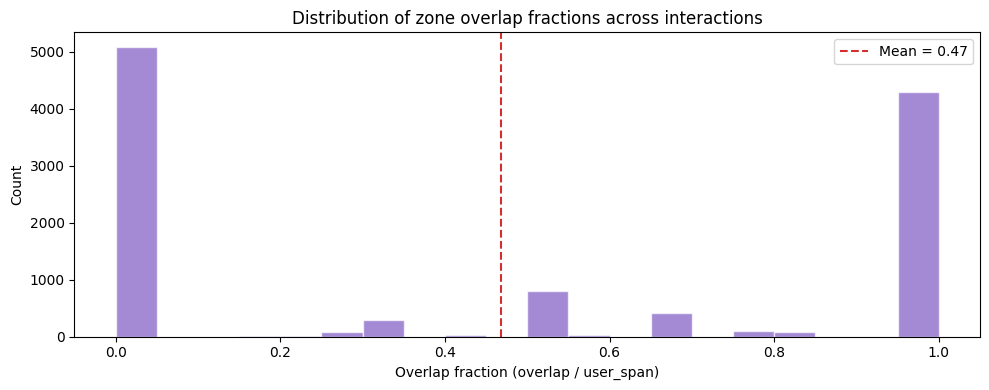

In [18]:
fractions = []
for r in interactions:
    u = user_by_id.get(r["user_id"], {})
    p = plant_by_id.get(r["plant_id"]) or {}
    if not p:
        continue
    result = compute_zone_overlap(u, p)
    if result is None:
        continue
    overlap, span = result
    fractions.append(overlap / span if span > 0 else 0.0)

fig, ax = plt.subplots(figsize=(10, 4), facecolor="white")
ax.hist(fractions, bins=20, color="#7e57c2", alpha=0.7, edgecolor="white")
ax.axvline(np.mean(fractions), color="#d32f2f", linestyle="--", linewidth=1.5, label=f"Mean = {np.mean(fractions):.2f}")
ax.set_xlabel("Overlap fraction (overlap / user_span)")
ax.set_ylabel("Count")
ax.set_title("Distribution of zone overlap fractions across interactions")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "zone_overlap_distribution.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

## 8. Summary

- **Oracle:** `zone_score = overlap / user_span` — continuous 0-1 credit proportional to how much of the user's zone range the plant can survive in.
- **Survival:** Should increase with overlap count. No overlap = worst, full overlap = best.
- **Model:** If the model learned the gradual zone effect, model scores should follow the same upward trend.
- **Distribution:** Shows how overlap fractions are spread — if most interactions cluster at 0 or 1, the partial signal is weak.